In [71]:
import os
import pandas as pd
import plotly.graph_objects as go
from typing import List, Optional, Dict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def find_config_file(folder_path: str) -> Optional[str]:
    """
    Finds a configuration file (ending with .txt) within the 'configs' subfolder.
    """
    config_dir = os.path.join(folder_path, 'configs')
    if not os.path.isdir(config_dir):
        return None
    for item in os.listdir(config_dir):
        if item.endswith('.txt'):
            return os.path.join(config_dir, item)
    return None

def parse_config(file_path: str) -> Dict[str, str]:
    """
    Parses a 'key = value', 'key value', or 'key: value' configuration file into a dictionary.
    """
    params = {}
    try:
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                
                separator = None
                if ':' in line:
                    separator = ':'
                elif '=' in line:
                    separator = '='

                if separator:
                    parts = line.split(separator, 1)
                else:
                    parts = line.split(None, 1)

                if len(parts) == 2:
                    key, value = parts
                    params[key.strip().lower()] = value.strip()
    except FileNotFoundError:
        print(f"Config file not found: {file_path}")
    except Exception as e:
        print(f"Error parsing config file {file_path}: {e}")
    return params

def find_timing_file(run_folder_path: str, sim_type: str) -> Optional[str]:
    """Finds the ...trace_matched_timing.csv file for a given run."""
    sim_output_dir = os.path.join(run_folder_path, sim_type.lower())
    if not os.path.isdir(sim_output_dir):
        return None
    for f in os.listdir(sim_output_dir):
        if 'trace_matched_timing.csv' in f:
            return os.path.join(sim_output_dir, f)
    return None

# --- Collective Info Parsing ---
def parse_collectives_log(log_path: str) -> Dict[str, Dict]:
    """Parses a duplicate_collectives.log file to extract signatures."""
    collective_info = {}
    try:
        with open(log_path, 'r') as f:
            lines = f.readlines()
            i = 0
            while i < len(lines):
                line = lines[i]
                workload_match = re.match(r'^Workload: (\S+)', line)
                if workload_match:
                    current_workload = workload_match.group(1)
                    # Look for signature on the next line
                    if (i + 1 < len(lines)) and (signature_match := re.match(r'^\s+Signature: \((.*)\)', lines[i+1])):
                        sig_content = signature_match.group(1).strip()
                        # Split signature into its three parts
                        parts = sig_content.rsplit(', ', 2)
                        if len(parts) == 3:
                            npu_tuples, comm_type, comm_size = parts
                            collective_info[current_workload] = {
                                'npu_tuples': npu_tuples.strip(),
                                'comm_type': comm_type.strip(),
                                'comm_size': comm_size.strip()
                            }
                i += 1
    except FileNotFoundError:
        print(f"Warning: Collectives log file not found at {log_path}")
    except Exception as e:
        print(f"Error parsing collectives log {log_path}: {e}")
    return collective_info

In [72]:
import re
import pandas as pd
from plotly.subplots import make_subplots

# --- Configuration ---
base_comparison_folders = [
    '/app/astra-sim/upc/output/comparison_run/experiment2/FoldedClos/multiple_collectives_deterministic',
]

# --- Helper Functions ---
cc_modes = {0: "PFC", 1: "DCQCN", 3: "HPCC", 7: "TIMELY", 8: "DCTCP", 10: "HPCC-PINT"}
workload_info_regex = re.compile(r'([a-zA-Z_]+)_size_(\d+)_group_(\d+)')

def parse_runtime(time_str: str) -> float:
    """Parses 'H:MM:SS.ffffff' into seconds."""
    if not time_str: return 0.0
    try:
        h, m, s = map(float, time_str.split(':'))
        return h * 3600 + m * 60 + s
    except (ValueError, IndexError):
        return 0.0

def process_simulation(folder: str, sim_type: str, summary_params: dict, topo_file: str, run_name: str, workload_name: str, comm_size: int, group_id: int) -> Optional[dict]:
    """Processes a single simulation run, extracts timing data, and returns a result dictionary."""
    timing_file = find_timing_file(folder, sim_type)
    if not timing_file:
        return None

    try:
        df = pd.read_csv(timing_file)
        if sim_type == 'ns3' and 'node_name' in df.columns:
            df = df[df['node_name'] != 'dummy_node'].copy()

        time_col = 'callback_tick'
        if time_col not in df.columns:
            return None

        df = df[df[time_col] > 100].copy()
        if df.empty:
            return None
            
        # Only use the last time registered for each NPU
        elapsed_times = df.groupby('sys_id')[time_col].max()
        if elapsed_times.empty:
            return None

        name = summary_params.get('collective', 'N/A').strip()

        return {
            'workload': name,
            'comm_size': comm_size,
            'comm_type': workload_name,
            'group_id': group_id,
            'npu_count': summary_params.get('npus count', 'N/A'),
            'topology': ('_'.join(topo_file.split('_')[1:]).rsplit('.', 1)[0]),
            'sim_type': sim_type.upper(),
            'run_name': run_name,
            'avg_time': elapsed_times.mean(),
            'max_time': elapsed_times.max(),
            'min_time': elapsed_times.min(),
            'std_dev': elapsed_times.std(),
            'execution_time': parse_runtime(summary_params.get('total runtime', '0:0:0.0')),
            'path': folder
        }
    except Exception as e:
        print(f"Error processing {sim_type} in {folder}: {e}")
        return None

# --- Data Collection Logic ---
all_run_folders = []
for base_folder in base_comparison_folders:
    for workload_folder in os.listdir(base_folder):
        workload_path = os.path.join(base_folder, workload_folder)
        if os.path.isdir(workload_path):
            all_run_folders.extend([os.path.join(workload_path, d) for d in os.listdir(workload_path) if os.path.isdir(os.path.join(workload_path, d))])

comparison_results = []
for folder in sorted(all_run_folders):
    run_summary_path = os.path.join(folder, 'run_summary.txt')
    if not os.path.exists(run_summary_path):
        continue

    summary_params = parse_config(run_summary_path)
    
    # Extract info from workload folder name
    workload_folder_name = os.path.basename(os.path.dirname(folder))
    workload_name, comm_size, group_id = 'N/A', -1, -1
    workload_match = workload_info_regex.match(workload_folder_name)
    if workload_match:
        workload_name = workload_match.group(1)
        comm_size = int(workload_match.group(2))
        group_id = int(workload_match.group(3))

    # Process all potential simulation types in the folder
    sim_dirs = [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d)) and d in ['analytical_unaware', 'g2', 'ns3']]

    for sim_type in sim_dirs:
        topo_file = "N/A"
        run_name = f"{sim_type.replace('_', ' ').title()}"

        if sim_type != 'analytical_unaware':
            topo_key = 'g2 topology file override' if sim_type == 'g2' else 'ns3 topology file override'
            topo_path = summary_params.get(topo_key, '')
            if 'all_paths' in topo_path: continue
            if not topo_path: continue
            topo_file = os.path.basename(topo_path)

            if sim_type == 'ns3':
                ns3_config_file = find_config_file(folder)
                if ns3_config_file:
                    ns3_params = parse_config(ns3_config_file)
                    run_name = (
                        f"NS3 (cc:{cc_modes.get(int(ns3_params.get('cc_mode', -1)), 'N/A')}, "
                        f"win:{ns3_params.get('has_win', 'N/A')}, adapt:{ns3_params.get('var_win', 'N/A')}, "
                        f"buf:{ns3_params.get('buffer_size', 'N/A')}, size:{ns3_params.get('packet_payload_size', 'N/A')})"
                    )
            else: # G2
                run_name = "G2"

        result = process_simulation(folder, sim_type, summary_params, topo_file, run_name, workload_name, comm_size, group_id)
        if result:
            comparison_results.append(result)

# --- Plotting Logic ---


--- Analyzing Divergence for: Maximum Time and Average Time ---

--- Workload Divergence Analysis (Max Time & Avg Time) ---


,Comm Type,Comm Size,Group ID,G2 Max (ms),NS3 Max (ms),Div Max,G2 Avg (ms),NS3 Avg (ms),Div Avg,Topo
16,all_reduce,134217728,4,100.461,99.289,-1.17%,83.793,85.122,+1.59%,FoldedClos_16_v1_Random
12,all_reduce,134217728,0,163.509,164.241,+0.45%,163.509,164.240,+0.45%,FoldedClos_16_v1_Random
0,all_gather,134217728,0,80.853,81.222,+0.46%,80.853,81.219,+0.45%,FoldedClos_16_v1_Random
18,all_reduce,33554432,0,40.877,41.086,+0.51%,40.877,41.084,+0.51%,FoldedClos_16_v1_Random
6,all_gather,33554432,0,20.213,20.321,+0.53%,20.213,20.318,+0.52%,FoldedClos_16_v1_Random
15,all_reduce,134217728,3,32.702,33.030,+1.00%,32.702,33.017,+0.96%,FoldedClos_16_v1_Random
21,all_reduce,33554432,3,8.175,8.263,+1.07%,8.175,8.260,+1.04%,FoldedClos_16_v1_Random
3,all_gather,134217728,3,16.171,16.385,+1.32%,16.171,16.357,+1.16%,FoldedClos_16_v1_Random
9,all_gather,33554432,3,4.043,4.104,+1.51%,4.043,4.092,+1.23%,FoldedClos_16_v1_Random
4,all_gather,134217728,4,48.874,52.018,+6.43%,37.993,39.413,+3.74%,FoldedClos_16_v1_Random



--- Generated LaTeX Tables ---

--- LaTeX: G2 vs NS3 Divergence Analysis ---
\begin{table}[!htbp]
\caption{G2 vs NS3 Divergence Analysis for Collective Operations (Max and Avg Time).}
\label{tab:g2_ns3_divergence}
\begin{tabular}{lcccccccc}
\hline
Comm Type & Size (B) & Group & G2 Max (ms) & NS3 Max (ms) & Div Max (\%) & G2 Avg (ms) & NS3 Avg (ms) & Div Avg (\%) \\
\hline
all\_reduce & 134,217,728 & 4 & 100.461 & 99.289 & -1.17 & 83.793 & 85.122 & +1.59 \\
all\_reduce & 134,217,728 & 0 & 163.509 & 164.241 & +0.45 & 163.509 & 164.240 & +0.45 \\
all\_gather & 134,217,728 & 0 & 80.853 & 81.222 & +0.46 & 80.853 & 81.219 & +0.45 \\
all\_reduce & 33,554,432 & 0 & 40.877 & 41.086 & +0.51 & 40.877 & 41.084 & +0.51 \\
all\_gather & 33,554,432 & 0 & 20.213 & 20.321 & +0.53 & 20.213 & 20.318 & +0.52 \\
all\_reduce & 134,217,728 & 3 & 32.702 & 33.030 & +1.00 & 32.702 & 33.017 & +0.96 \\
all\_reduce & 33,554,432 & 3 & 8.175 & 8.263 & +1.07 & 8.175 & 8.260 & +1.04 \\
all\_gather & 134,217,728 & 3 &

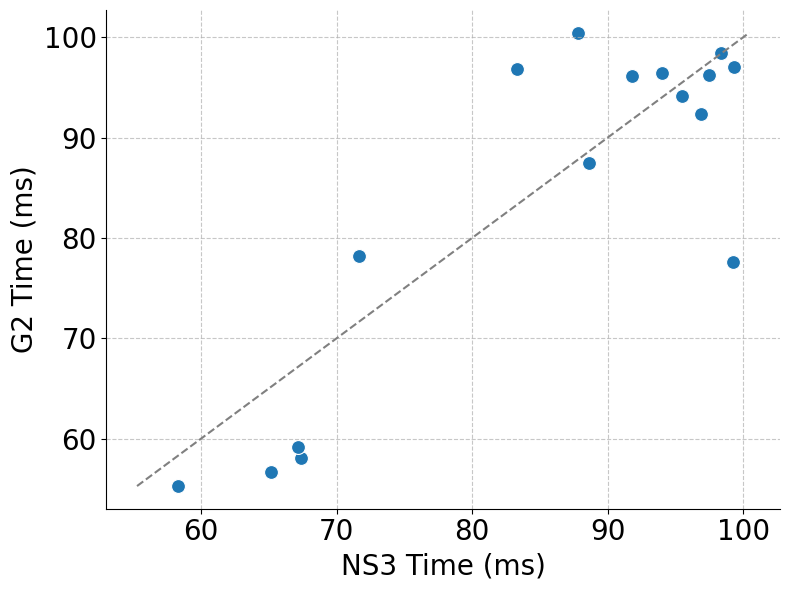


Generating scatter plot for multiple_collectives_deterministic/all_reduce_size_134217728_group_0 (Group 0, Topology: FoldedClos_16_v1_Random)


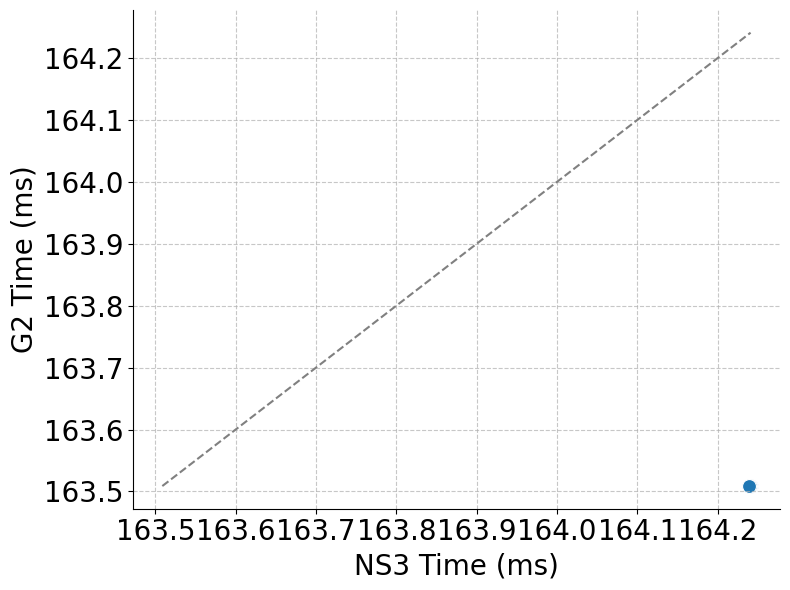


Generating scatter plot for multiple_collectives_deterministic/all_gather_size_134217728_group_0 (Group 0, Topology: FoldedClos_16_v1_Random)


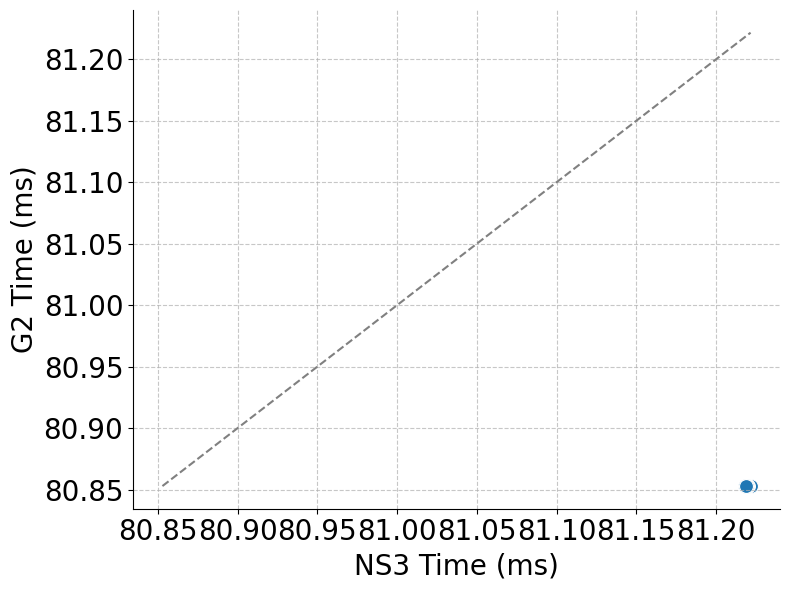


Generating scatter plot for multiple_collectives_deterministic/all_reduce_size_33554432_group_0 (Group 0, Topology: FoldedClos_16_v1_Random)


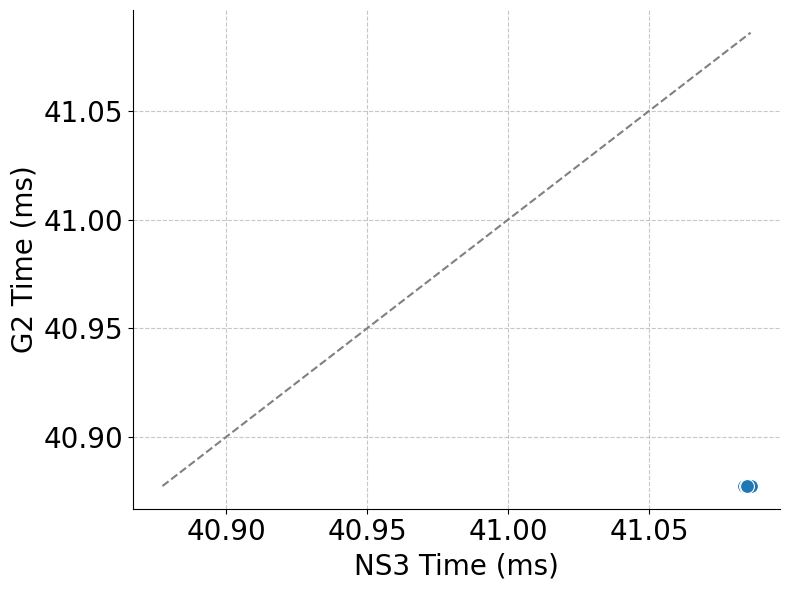


Generating scatter plot for multiple_collectives_deterministic/all_gather_size_33554432_group_0 (Group 0, Topology: FoldedClos_16_v1_Random)


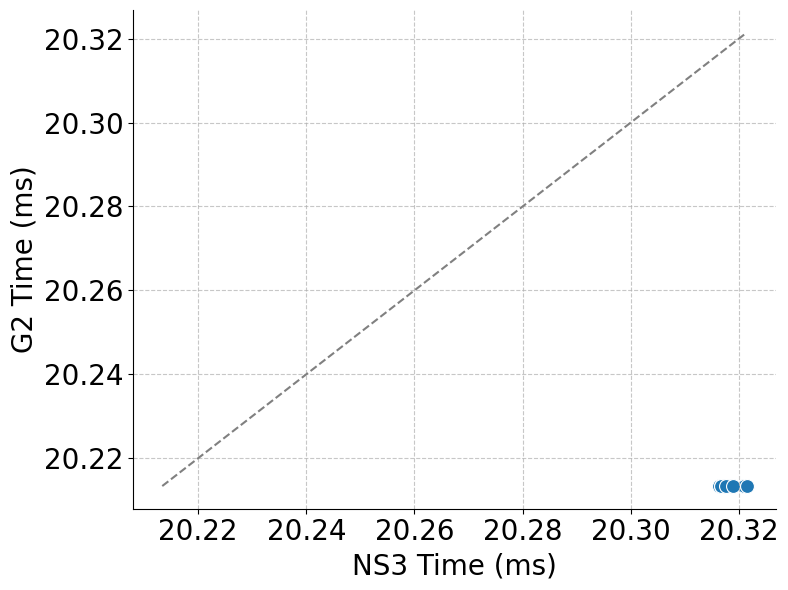


Generating scatter plot for multiple_collectives_deterministic/all_reduce_size_134217728_group_3 (Group 3, Topology: FoldedClos_16_v1_Random)


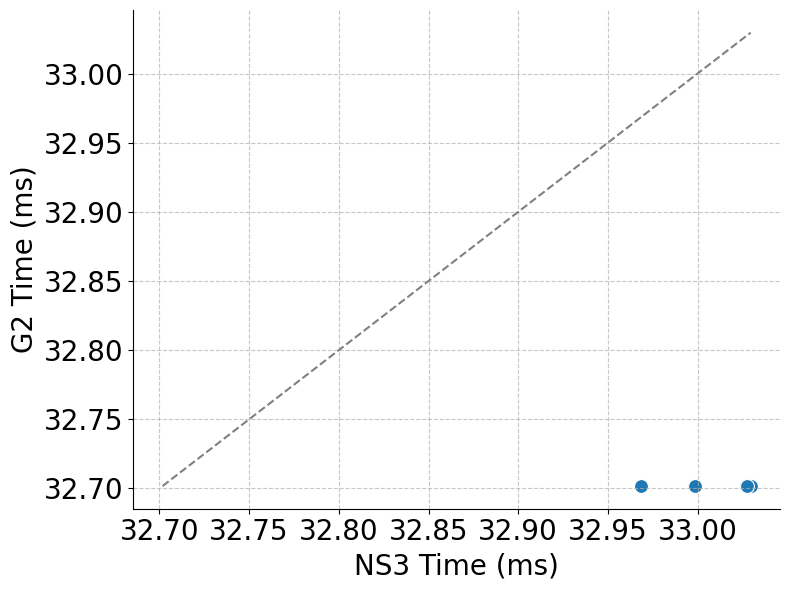


Generating scatter plot for multiple_collectives_deterministic/all_reduce_size_33554432_group_3 (Group 3, Topology: FoldedClos_16_v1_Random)


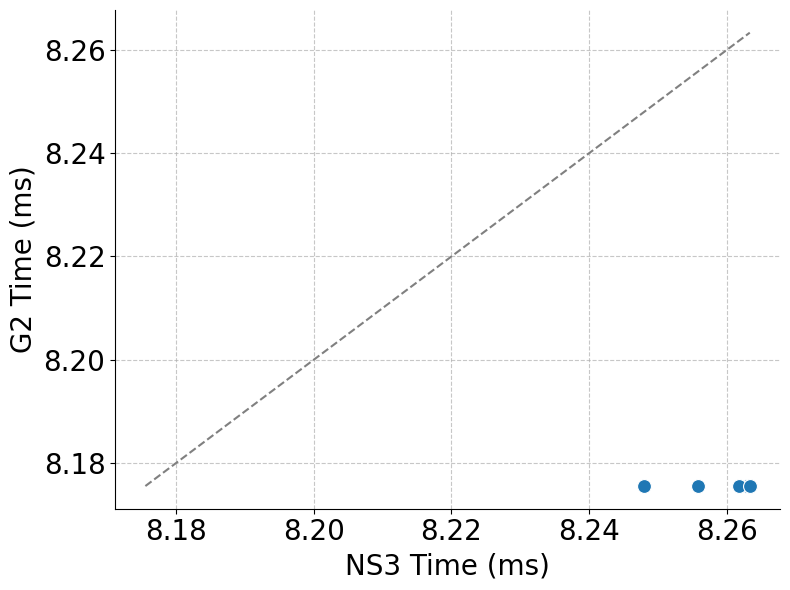


Generating scatter plot for multiple_collectives_deterministic/all_gather_size_134217728_group_3 (Group 3, Topology: FoldedClos_16_v1_Random)


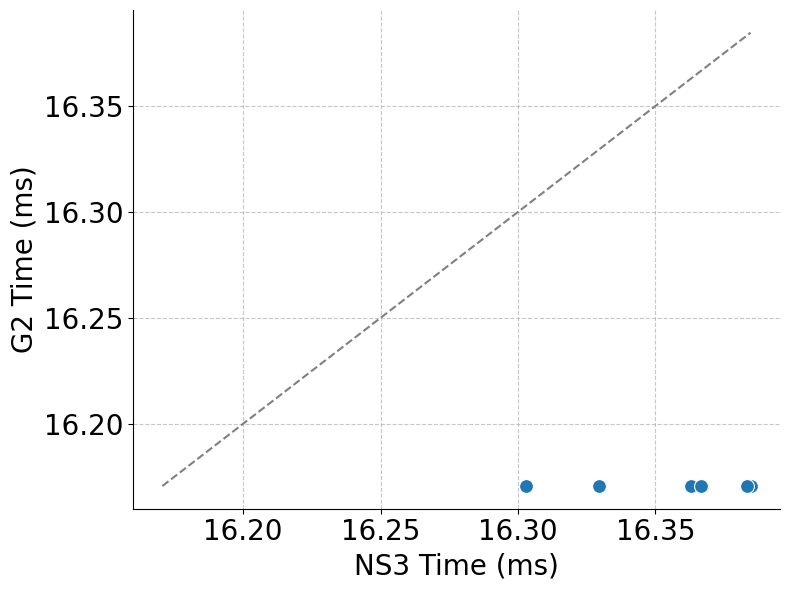


Generating scatter plot for multiple_collectives_deterministic/all_gather_size_33554432_group_3 (Group 3, Topology: FoldedClos_16_v1_Random)


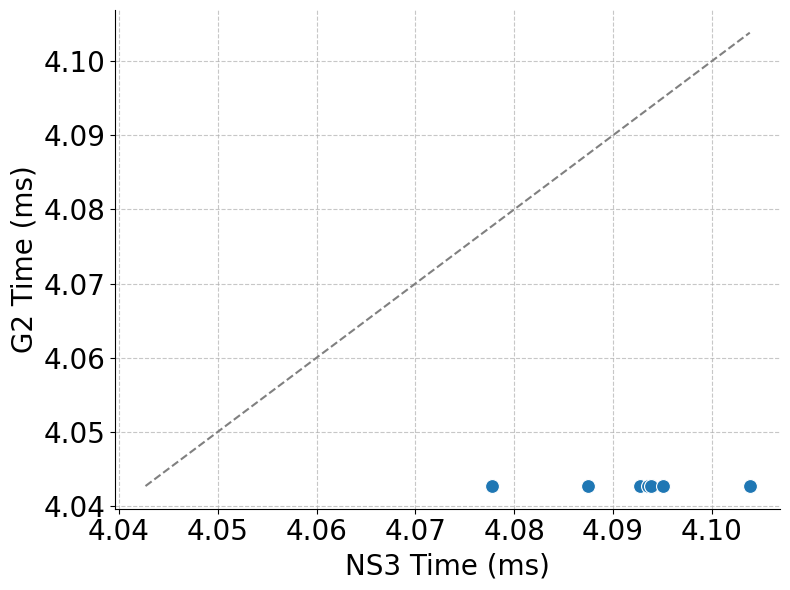


Generating scatter plot for multiple_collectives_deterministic/all_gather_size_134217728_group_4 (Group 4, Topology: FoldedClos_16_v1_Random)


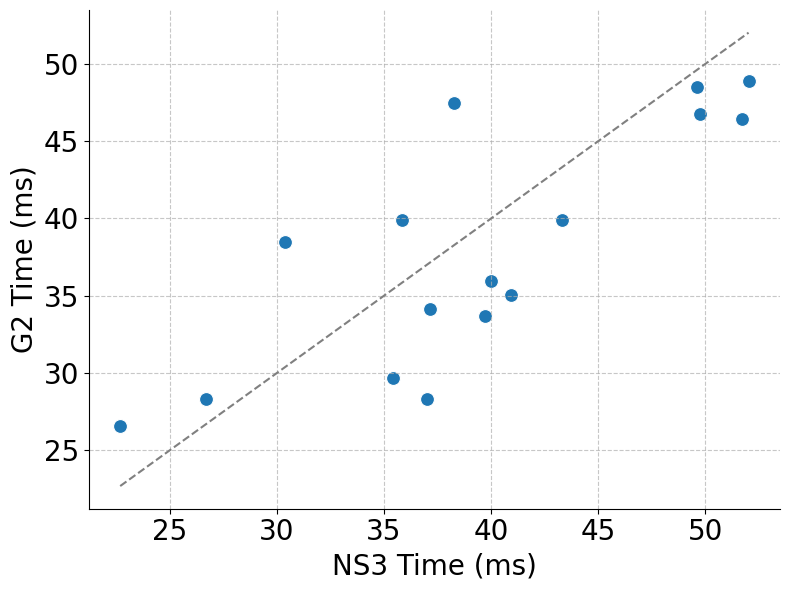


Generating scatter plot for multiple_collectives_deterministic/all_gather_size_134217728_group_5 (Group 5, Topology: FoldedClos_16_v1_Random)


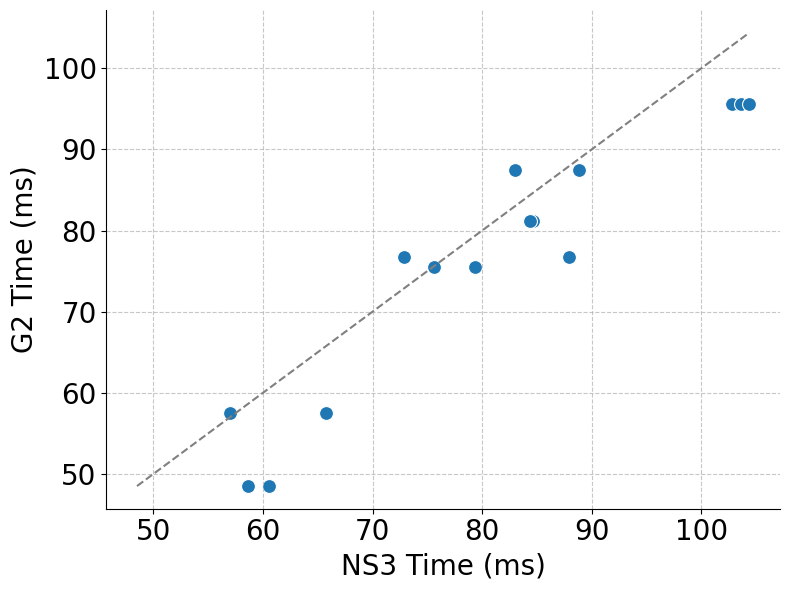


Generating scatter plot for multiple_collectives_deterministic/all_reduce_size_134217728_group_5 (Group 5, Topology: FoldedClos_16_v1_Random)


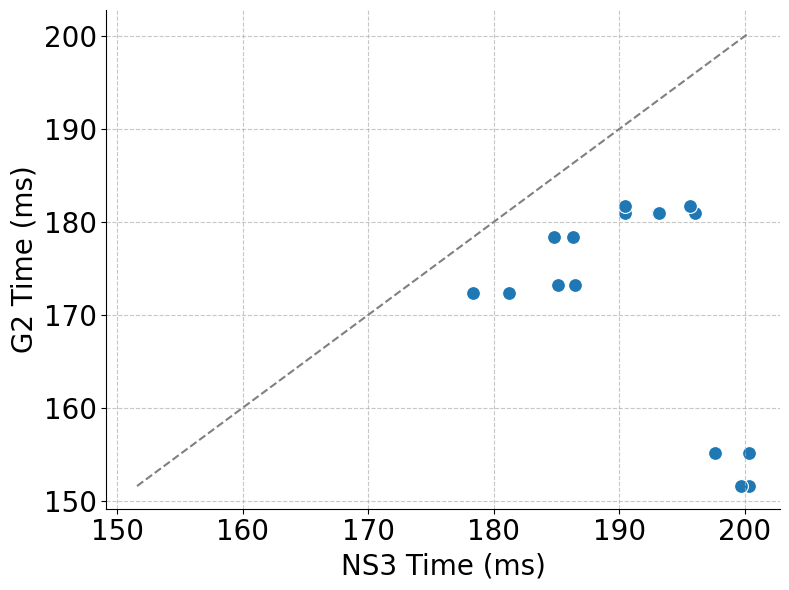

In [75]:
# --- Analysis and Plotting ---
if comparison_results:
    comp_df = pd.DataFrame(comparison_results)

    # Map for collective communication types
    comm_type_map = {
        "all_reduce": "ALL_REDUCE", "reduce": "REDUCE", "all_gather": "ALL_GATHER", "gather": "GATHER",
        "scatter": "SCATTER", "broadcast": "BROADCAST", "all_to_all": "ALL_TO_ALL", "reduce_scatter": "REDUCE_SCATTER",
        "reduce_scatter_block": "REDUCE_SCATTER_BLOCK", "barrier": "BARRIER"
    }
    comp_df['comm_type_str'] = comp_df['comm_type'].astype(str).map(comm_type_map).fillna(comp_df['comm_type'])

    # --- Divergence Analysis (per topology) for BOTH max_time and avg_time ---
    print(f"--- Analyzing Divergence for: Maximum Time and Average Time ---")
    
    divergence_data = []
    # Group by workload, group_id, and topology to compare G2 and NS3 for each specific case
    for group_keys, group_df in comp_df.groupby(['workload', 'group_id', 'topology']):
        wl, gid, topo = group_keys
        
        g2_runs = group_df[group_df['sim_type'] == 'G2']
        ns3_runs = group_df[group_df['sim_type'] == 'NS3']

        if g2_runs.empty or ns3_runs.empty:
            continue

        # There should be only one G2 run per group
        g2_run = g2_runs.iloc[0]
        g2_max_time = g2_run['max_time']
        g2_avg_time = g2_run['avg_time']

        # Find the best (minimum time) NS3 run within this group for max_time
        best_ns3_run_max = ns3_runs.loc[ns3_runs['max_time'].idxmin()]
        best_ns3_max_time = best_ns3_run_max['max_time']
        
        # Find the best (minimum time) NS3 run within this group for avg_time
        best_ns3_run_avg = ns3_runs.loc[ns3_runs['avg_time'].idxmin()]
        best_ns3_avg_time = best_ns3_run_avg['avg_time']

        if g2_max_time < 100 or best_ns3_max_time < 100:
            continue

        divergence_max = (best_ns3_max_time - g2_max_time) / g2_max_time
        divergence_avg = (best_ns3_avg_time - g2_avg_time) / g2_avg_time if g2_avg_time > 100 else np.nan
        
        divergence_data.append({
            'Workload': wl,
            'Comm Type': g2_run.get('comm_type', 'N/A'),
            'Comm Size': g2_run.get('comm_size', 'N/A'),
            'Group ID': gid,
            'Topo': topo,
            'G2 Max Time': g2_max_time,
            'G2 Avg Time': g2_avg_time,
            'Best NS3 Max Time': best_ns3_max_time,
            'Best NS3 Avg Time': best_ns3_avg_time,
            'Best NS3 Run (Max)': best_ns3_run_max['run_name'],
            'Best NS3 Run (Avg)': best_ns3_run_avg['run_name'],
            'Divergence Max': divergence_max,
            'Divergence Avg': divergence_avg,
            'npu_tuples': g2_run.get('npu_tuples', 'N/A'),
            'g2_path': g2_run['path'],
            'ns3_path': best_ns3_run_max['path']
        })

    if not divergence_data:
        print(f"No divergent workloads found.\n")
    else:
        div_df = pd.DataFrame(divergence_data).sort_values(by='Divergence Max', ascending=True)

        # --- Display The New Table ---
        display_df = div_df.copy()
        # Convert times to ms and format divergence
        display_df['G2 Max (ms)'] = display_df['G2 Max Time'] / 1_000_000
        display_df['G2 Avg (ms)'] = display_df['G2 Avg Time'] / 1_000_000
        display_df['NS3 Max (ms)'] = display_df['Best NS3 Max Time'] / 1_000_000
        display_df['NS3 Avg (ms)'] = display_df['Best NS3 Avg Time'] / 1_000_000
        display_df['Div Max'] = display_df['Divergence Max'].apply(lambda x: f"{x:+.2%}")
        display_df['Div Avg'] = display_df['Divergence Avg'].apply(lambda x: f"{x:+.2%}" if pd.notna(x) else "N/A")

        print(f"\n--- Workload Divergence Analysis (Max Time & Avg Time) ---")
        with pd.option_context('display.float_format', '{:,.3f}'.format):
            display(display_df[[
                'Comm Type', 'Comm Size', 'Group ID', 
                'G2 Max (ms)', 'NS3 Max (ms)', 'Div Max',
                'G2 Avg (ms)', 'NS3 Avg (ms)', 'Div Avg',
                'Topo'
            ]])

        # --- Generate LaTeX Table ---
        print(f"\n{'='*80}\n--- Generated LaTeX Tables ---\n{'='*80}")
        
        # Prepare LaTeX DataFrame
        latex_df = pd.DataFrame()
        latex_df['Comm Type'] = div_df['Comm Type'].str.replace('_', '\\_')
        latex_df['Size (B)'] = div_df['Comm Size']
        latex_df['Group'] = div_df['Group ID']
        latex_df['G2 Max (ms)'] = div_df['G2 Max Time'] / 1_000_000
        latex_df['NS3 Max (ms)'] = div_df['Best NS3 Max Time'] / 1_000_000
        latex_df['Div Max (\\%)'] = div_df['Divergence Max'] * 100
        latex_df['G2 Avg (ms)'] = div_df['G2 Avg Time'] / 1_000_000
        latex_df['NS3 Avg (ms)'] = div_df['Best NS3 Avg Time'] / 1_000_000
        latex_df['Div Avg (\\%)'] = div_df['Divergence Avg'] * 100
        
        # Add summary row with MAPE (Mean Absolute Percentage Error)
        mape_max = div_df['Divergence Max'].abs().mean() * 100
        mape_avg = div_df['Divergence Avg'].abs().mean() * 100
        avg_row = pd.DataFrame([{
            'Comm Type': '\\textbf{MAPE}',
            'Size (B)': '',
            'Group': '',
            'G2 Max (ms)': latex_df['G2 Max (ms)'].mean(),
            'NS3 Max (ms)': latex_df['NS3 Max (ms)'].mean(),
            'Div Max (\\%)': mape_max,
            'G2 Avg (ms)': latex_df['G2 Avg (ms)'].mean(),
            'NS3 Avg (ms)': latex_df['NS3 Avg (ms)'].mean(),
            'Div Avg (\\%)': mape_avg
        }])
        latex_df = pd.concat([latex_df, avg_row], ignore_index=True)
        
        # Generate LaTeX
        latex_table = latex_df.to_latex(
            index=False,
            formatters={
                'Size (B)': lambda x: f"{x:,}" if isinstance(x, (int, float)) and x != '' else str(x),
                'Group': lambda x: str(int(x)) if isinstance(x, (int, float)) and x != '' else str(x),
                'G2 Max (ms)': "{:.3f}".format,
                'NS3 Max (ms)': "{:.3f}".format,
                'Div Max (\\%)': "{:+.2f}".format,
                'G2 Avg (ms)': "{:.3f}".format,
                'NS3 Avg (ms)': "{:.3f}".format,
                'Div Avg (\\%)': "{:+.2f}".format,
            },
            caption='G2 vs NS3 Divergence Analysis for Collective Operations (Max and Avg Time).',
            label='tab:g2_ns3_divergence',
            position='!htbp',
            column_format='lcccccccc',
            escape=False
        )
        
        # Add hline before the last row (MAPE)
        lines = latex_table.splitlines()
        lines.insert(-2, '\\hline')
        latex_table = '\n'.join(lines)
        latex_table = latex_table.replace('\\toprule', '\\hline').replace('\\midrule', '\\hline').replace('\\bottomrule', '\\hline')
        
        print(f"\n--- LaTeX: G2 vs NS3 Divergence Analysis ---")
        print(latex_table)
        
        # Print summary statistics
        print(f"\n--- Summary Statistics ---")
        print(f"Mean Absolute Percentage Error (MAPE) for Max Time: {mape_max:.2f}%")
        print(f"Mean Absolute Percentage Error (MAPE) for Avg Time: {mape_avg:.2f}%")
        print(f"Mean Divergence (Max Time): {div_df['Divergence Max'].mean()*100:+.2f}%")
        print(f"Mean Divergence (Avg Time): {div_df['Divergence Avg'].mean()*100:+.2f}%")

        # --- Plotting Logic for All Divergent Cases ---
        print(f"\n--- Generating Plots for All Divergent Workloads ---")

        for _, row in div_df.head(12).iterrows():
            g2_timing_file = find_timing_file(row['g2_path'], 'G2')
            ns3_timing_file = find_timing_file(row['ns3_path'], 'NS3')

            if g2_timing_file and ns3_timing_file:
                try:
                    print(f"\nGenerating scatter plot for {row['Workload']} (Group {row['Group ID']}, Topology: {row['Topo']})")
                    df_g2_raw = pd.read_csv(g2_timing_file)[['sys_id', 'callback_tick']]
                    df_g2_raw = df_g2_raw[df_g2_raw['callback_tick'] > 100]
                    df_g2 = df_g2_raw.groupby('sys_id')['callback_tick'].max().reset_index().rename(columns={'callback_tick': 'g2_time'})
                    
                    df_ns3_raw = pd.read_csv(ns3_timing_file)[['sys_id', 'callback_tick']]
                    df_ns3_raw = df_ns3_raw[df_ns3_raw['callback_tick'] > 100]
                    df_ns3 = df_ns3_raw.groupby('sys_id')['callback_tick'].max().reset_index().rename(columns={'callback_tick': 'ns3_time'})
                    
                    merged_df = pd.merge(df_ns3, df_g2, on='sys_id')
                    merged_df = merged_df[(merged_df['ns3_time'] >= 100) & (merged_df['g2_time'] >= 100)]
                    
                    merged_df['g2_time_ms'] = merged_df['g2_time'] / 1_000_000
                    merged_df['ns3_time_ms'] = merged_df['ns3_time'] / 1_000_000

                    plt.figure(figsize=(8, 6))
                    sns.scatterplot(data=merged_df, x='ns3_time_ms', y='g2_time_ms', s=100)
                    
                    min_val = min(merged_df['ns3_time_ms'].min(), merged_df['g2_time_ms'].min())
                    max_val = max(merged_df['ns3_time_ms'].max(), merged_df['g2_time_ms'].max())
                    
                    plt.plot([min_val, max_val], [min_val, max_val], color='grey', linestyle='--', label='y=x')
                    
                    # plt.title(f"{row['Workload']} (Group {row['Group ID']})", fontsize=16)
                    plt.xlabel("NS3 Time (ms)", fontsize=20)
                    plt.ylabel("G2 Time (ms)", fontsize=20)
                    plt.xticks(fontsize=20)
                    plt.yticks(fontsize=20)
                    plt.grid(axis='both', linestyle='--', alpha=0.7)
                    sns.despine()
                    plt.tight_layout()
                    plt.show()

                except Exception as e:
                    print(f"Could not create scatter plot for {row['Workload']}: {e}")
        
        print("\n" + "="*80 + "\n")

else:
    print("No comparison results to process.")



In [74]:
comp_df['sim_type'].unique()
comp_df['sim_type'].nunique()
comp_df['sim_type'].value_counts()

sim_type
G2                    24
ANALYTICAL_UNAWARE    24
NS3                   24
Name: count, dtype: int64